In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

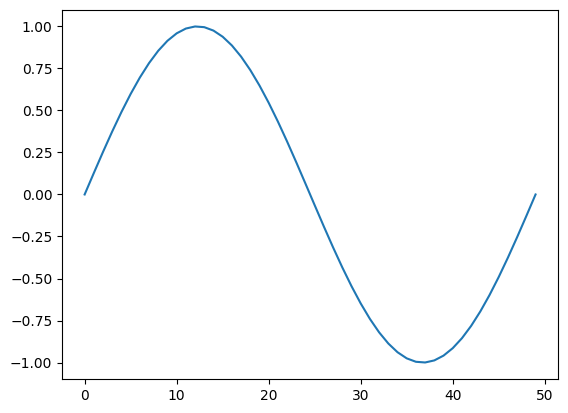

In [4]:
def generate_data(seq_length):
    x = np.linspace(0, 2* np.pi, seq_length)
    y = np.sin(x)
    return y

seq_length = 50
data = generate_data(seq_length)
plt.plot(data)
plt.show()

In [16]:
def prepare_data(data, sequence_length):
    x , y = [], []
    for i in range(len(data) - sequence_length):
        x.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return torch.tensor(x, dtype= torch.float32), torch.tensor(y, dtype = torch.float32)

sequence_length = 10
x, y = prepare_data(data, sequence_length)

In [17]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_size)
        c0 = torch.zeros(1, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # 마지막 타임스텝의 출력 사용
        return out

# 하이퍼파라미터 설정
input_size = 1
hidden_size = 32
output_size = 1
model = LSTM(input_size, hidden_size, output_size)




In [18]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 데이터 차원 변환
x = x.unsqueeze(-1)  # (batch_size, sequence_length, input_size)

# 학습 과정
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    output = model(x)
    loss = criterion(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

/home/binghin2/miniconda3/envs/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([40])) that is different to the input size (torch.Size([40, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [20/200], Loss: 0.5093
Epoch [40/200], Loss: 0.5092
Epoch [60/200], Loss: 0.5092
Epoch [80/200], Loss: 0.5092
Epoch [100/200], Loss: 0.5092
Epoch [120/200], Loss: 0.5092
Epoch [140/200], Loss: 0.5092
Epoch [160/200], Loss: 0.5092
Epoch [180/200], Loss: 0.5092
Epoch [200/200], Loss: 0.5092


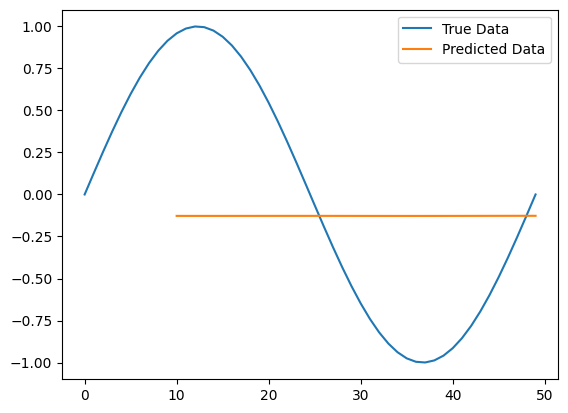

In [19]:
model.eval()
with torch.no_grad():
    predictions = model(x).detach().numpy()

plt.plot(data, label="True Data")
plt.plot(range(sequence_length, len(data)), predictions, label="Predicted Data")
plt.legend()
plt.show()
